# MVP Análise de Dados e Boas Práticas

**Nome:** Wesley Ramos Neres Santiago

**Matrícula:** 4052025002507

**Dataset:** [Credit Risk Dataset](https://www.kaggle.com/datasets/laotse/credit-risk-dataset)


# Descrição do Problema

O risco de crédito representa a possibilidade de um tomador não honrar
suas obrigações financeiras, caracterizando o chamado **default**
(inadimplência). A capacidade de prever a probabilidade de default é
estratégica para instituições financeiras, pois orienta decisões de
concessão de crédito, precificação de risco e gestão de carteira.

Este trabalho utiliza o **Credit Risk Dataset** (Kaggle) para realizar
uma análise exploratória completa e um pipeline de pré-processamento,
com foco em preparar os dados para um futuro modelo de classificação
capaz de estimar a probabilidade de default de um cliente pessoa física.

## Hipóteses do Problema

As hipóteses que tracei são as seguintes:

1. **Tomadores com maior comprometimento de renda (DTI) apresentam maior probabilidade de default** — o quanto da renda é comprometido com o empréstimo é um indicador direto de capacidade de pagamento.

2. **Clientes com histórico de default anterior têm maior taxa de inadimplência futura** — comportamento passado de crédito é o melhor preditor de comportamento futuro.

3. **A taxa de default cresce progressivamente do loan grade A ao G** — a classificação de risco atribuída no momento da concessão reflete com fidelidade o risco real de inadimplência.

4. **Empréstimos para fins médicos e consolidação de dívidas apresentam maior taxa de default** — essas finalidades tendem a indicar estresse financeiro preexistente do tomador.

5. **Clientes mais jovens apresentam maior risco de default** — menor estabilidade de renda e histórico de crédito mais curto aumentam a vulnerabilidade financeira.

6. **O dataset apresenta desbalanceamento de classes** — em carteiras de crédito saudáveis, inadimplentes são sempre a classe minoritária.

## Tipo de Problema

Este é um problema de **classificação binária supervisionada**. O objetivo
é prever se um tomador de crédito irá ou não entrar em default, com base
em seus atributos cadastrais e características do empréstimo solicitado.

A variável-alvo é `loan_status`:
- `0` → **Adimplente**: cliente honrou suas obrigações financeiras
- `1` → **Inadimplente**: cliente entrou em default

## Seleção de Dados

O dataset utilizado é o **Credit Risk Dataset**, disponível publicamente
no Kaggle. É composto por dados sintéticos que simulam uma carteira de
crédito ao consumidor pessoa física, com ~32.500 registros e 12 atributos.

Critérios que motivaram a escolha:
- Contém variável-alvo binária de default claramente definida
- Apresenta mix de atributos numéricos e categóricos
- Possui valores faltantes e outliers, viabilizando um pipeline completo de pré-processamento


Premissas adotadas:
- O dataset é tratado como corte transversal, sem análise de safra
- O escopo é restrito à probabilidade de default — LGD e EAD estão fora do escopo
- A janela de observação do default é assumida como 12 meses

## Atributos do Dataset

| Atributo | Tipo | Descrição |
|----------|------|-----------|
| `person_age` | Numérico | Idade do solicitante em anos |
| `person_income` | Numérico | Renda anual declarada (USD) |
| `person_home_ownership` | Categórico | Situação de moradia: RENT, OWN, MORTGAGE, OTHER |
| `person_emp_length` | Numérico | Tempo de emprego em anos |
| `loan_intent` | Categórico | Finalidade: PERSONAL, EDUCATION, MEDICAL, VENTURE, HOMEIMPROVEMENT, DEBTCONSOLIDATION |
| `loan_grade` | Ordinal | Classificação de risco: A (menor risco) → G (maior risco) |
| `loan_amnt` | Numérico | Valor do empréstimo solicitado (USD) |
| `loan_int_rate` | Numérico | Taxa de juros anual do empréstimo (%) |
| `loan_status` | Binário | **Variável-alvo**: 0 = adimplente, 1 = inadimplente |
| `loan_percent_income` | Numérico | Proporção do valor do empréstimo sobre a renda anual (DTI) |
| `cb_person_default_on_file` | Binário | Histórico de default anterior: Y = sim, N = não |
| `cb_person_cred_hist_length` | Numérico | Tempo de histórico de crédito em anos |

# Importação das Bibliotecas Necessárias e Carga de Dados

Esta seção consolida todas as importações de bibliotecas necessárias
para a análise, visualização e pré-processamento dos dados, bem como
o carregamento inicial do dataset.

In [45]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA

In [46]:
# carregamento do dataset direto do Kaggle
import kagglehub
import os

path = kagglehub.dataset_download('laotse/credit-risk-dataset')
csv_file = [f for f in os.listdir(path) if f.endswith('.csv')][0]

# guardo o dataset em um dataframe
df_raw = pd.read_csv(os.path.join(path, csv_file))
df = df_raw.copy()

Using Colab cache for faster access to the 'credit-risk-dataset' dataset.


In [47]:
# primeiras linhas
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


# Análise de Dados

## Total e Tipo das Instâncias

In [48]:
# dimensões do dataset
print(f'Instâncias : {df.shape[0]:,}')
print(f'Atributos  : {df.shape[1]}')

# tipos de dados e valores nulos
resumo = pd.DataFrame({
    'Tipo'       : df.dtypes,
    'Nulos'      : df.isnull().sum(),
    '% Nulos'    : (df.isnull().sum() / len(df) * 100).round(2)
})
print('\n', resumo.to_string())

Instâncias : 32,581
Atributos  : 12

                                Tipo  Nulos  % Nulos
person_age                    int64      0     0.00
person_income                 int64      0     0.00
person_home_ownership        object      0     0.00
person_emp_length           float64    895     2.75
loan_intent                  object      0     0.00
loan_grade                   object      0     0.00
loan_amnt                     int64      0     0.00
loan_int_rate               float64   3116     9.56
loan_status                   int64      0     0.00
loan_percent_income         float64      0     0.00
cb_person_default_on_file    object      0     0.00
cb_person_cred_hist_length    int64      0     0.00


O dataset contém 32.581 instâncias e 12 atributos, sendo 7 numéricos
e 5 categóricos/binários. Dois atributos apresentam valores faltantes:
`loan_int_rate` (9,6%) e `person_emp_length` (2,7%). Ambos serão
tratados na seção de pré-processamento.


## Estatísticas Descritivas

In [49]:
# resumo estatístico dos atributos numéricos
num_cols = df.select_dtypes(include=np.number).columns.tolist()

desc = df[num_cols].describe(percentiles=[0.25, 0.5, 0.75]).T
desc['skewness'] = df[num_cols].apply(stats.skew).round(3)
desc['kurtosis'] = df[num_cols].apply(stats.kurtosis).round(3)
desc['nulos']    = df[num_cols].isnull().sum()

desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max', 'skewness', 'kurtosis', 'nulos']].round(2)

,mean,std,min,25%,50%,75%,max,skewness,kurtosis,nulos
person_age,27.73,6.35,20.00,23.00,26.00,30.00,144.00,2.58,18.56,0
person_income,66074.85,61983.12,4000.00,38500.00,55000.00,79200.00,6000000.00,32.86,2692.86,0
person_emp_length,4.79,4.14,0.00,2.00,4.00,7.00,123.00,NaN,NaN,895
loan_amnt,9589.37,6322.09,500.00,5000.00,8000.00,12200.00,35000.00,1.19,1.42,0
loan_int_rate,11.01,3.24,5.42,7.90,10.99,13.47,23.22,NaN,NaN,3116
loan_status,0.22,0.41,0.00,0.00,0.00,0.00,1.00,1.36,-0.14,0
loan_percent_income,0.17,0.11,0.00,0.09,0.15,0.23,0.83,1.06,1.22,0
cb_person_cred_hist_length,5.80,4.06,2.00,3.00,4.00,8.00,30.00,1.66,3.72,0


Alguns pontos chamam atenção imediatamente:

- `person_age` tem valor máximo de 144 anos — fisicamente impossível,
indicando outliers extremos que precisam ser tratados.
- `person_emp_length` tem máximo de 123 anos — mesma situação.
- `person_income` apresenta skewness muito elevado, confirmando
distribuição fortemente assimétrica à direita — típico de variáveis
de renda. Uma transformação logarítmica será avaliada.
- `loan_int_rate` tem desvio padrão de ~6pp, refletindo a
diferenciação de risco entre tomadores na carteira.

### Histograma

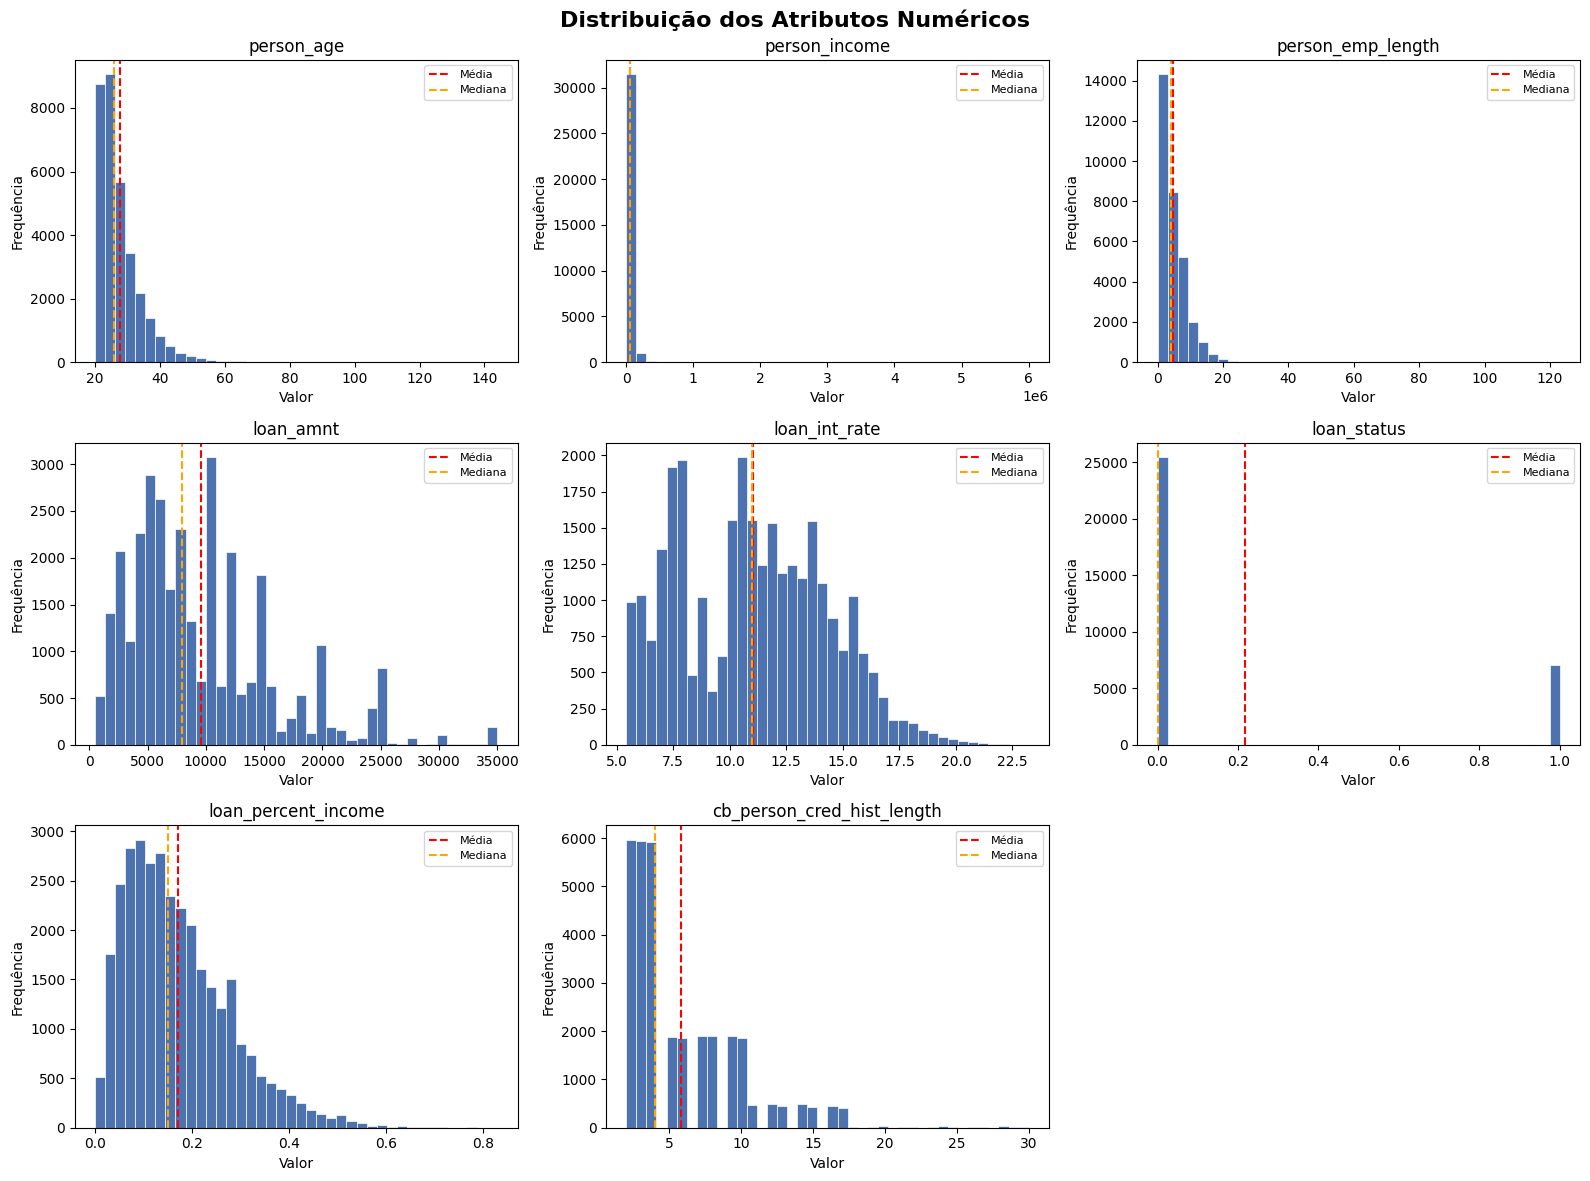

In [50]:
# histogramas dos atributos numéricos
fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col].dropna(), bins=40,
                 color='#4C72B0', edgecolor='white', linewidth=0.5)
    axes[i].axvline(df[col].mean(),   color='red',    linestyle='--',
                    linewidth=1.5, label='Média')
    axes[i].axvline(df[col].median(), color='orange', linestyle='--',
                    linewidth=1.5, label='Mediana')
    axes[i].set_title(col)
    axes[i].set_xlabel('Valor')
    axes[i].set_ylabel('Frequência')
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuição dos Atributos Numéricos', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Os histogramas trazem padrões relevantes:

- `person_age` e `person_emp_length`: caudas direitas extremamente
longas confirmam os outliers impossíveis detectados no resumo
estatístico. A distância entre média e mediana evidencia o impacto
desses valores sobre a média.
- `person_income` e `loan_amnt`: forte assimetria positiva — a maioria
dos tomadores concentra-se em faixas mais baixas, com poucos casos
de valores muito altos.
- `loan_int_rate`: distribuição bimodal, sugerindo dois perfis
distintos de tomadores, possivelmente separados pelo `loan_grade`.
- `loan_percent_income`: concentração próxima de zero com cauda longa,
indicando que a maioria tem comprometimento de renda moderado, mas
há casos críticos de alto endividamento.

### Boxplot

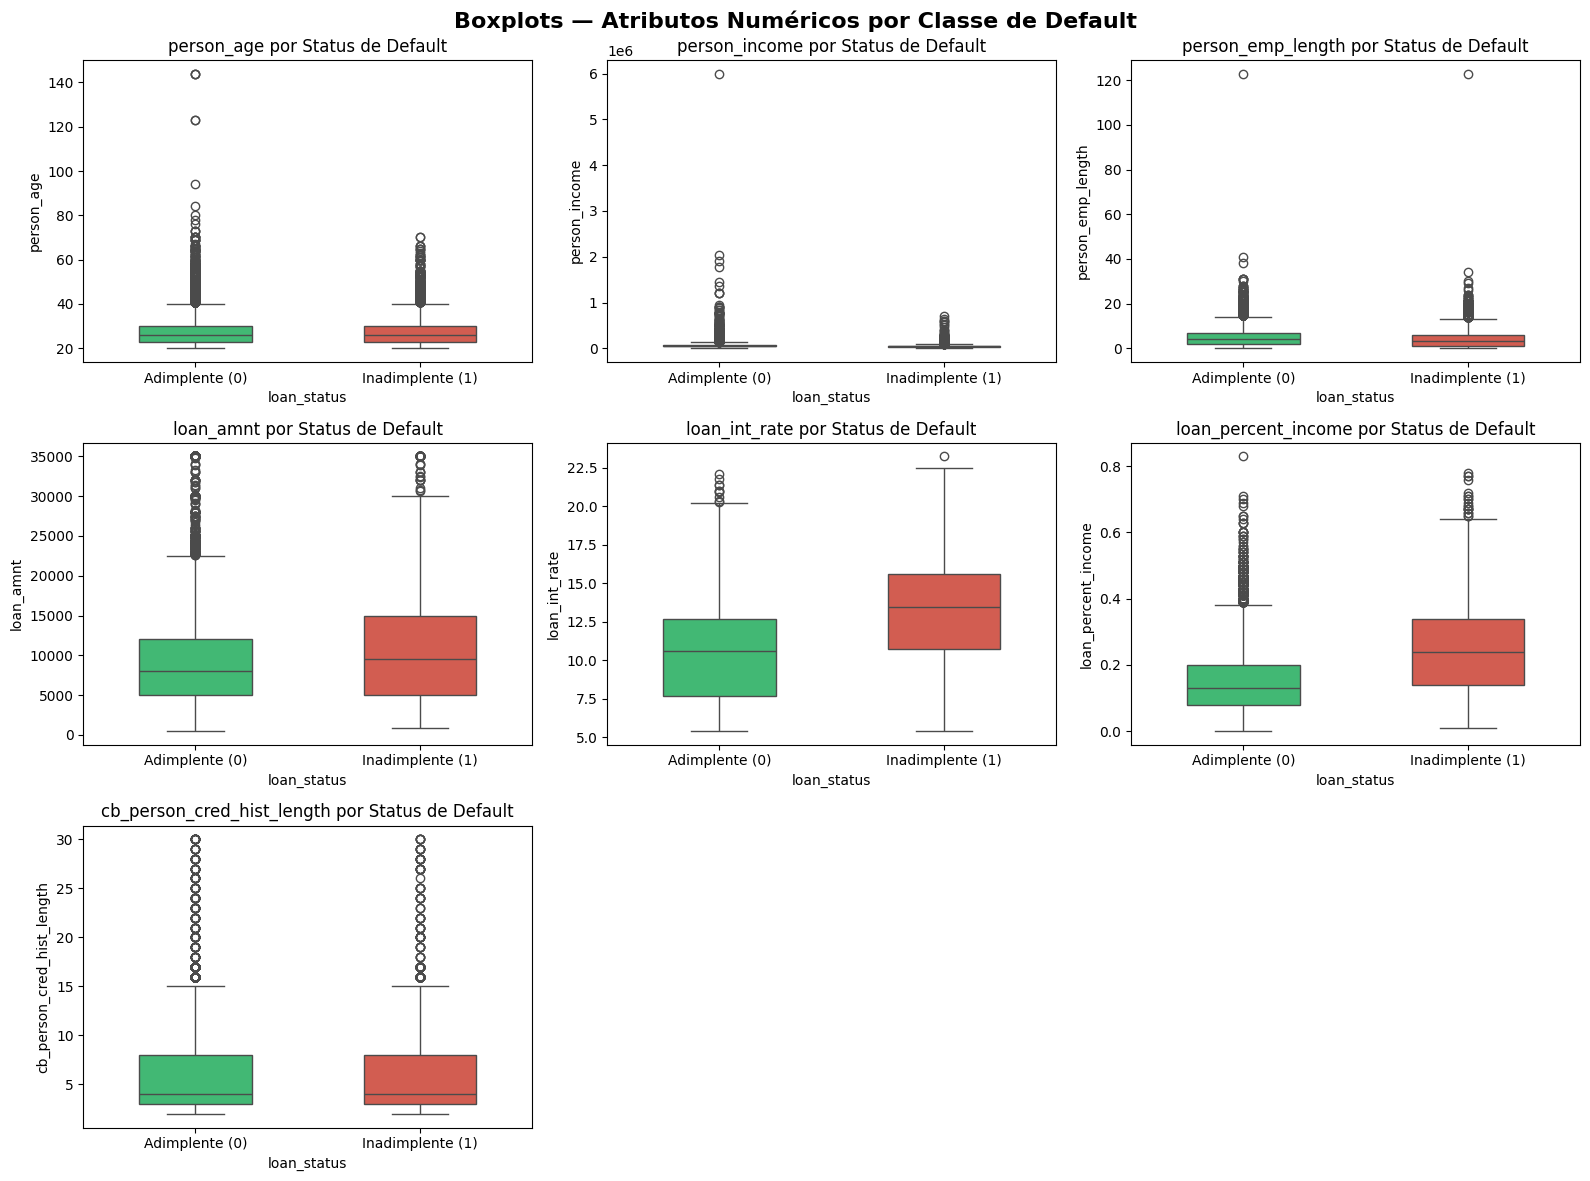

In [51]:
# boxplots dos atributos numéricos estratificados pela variável-alvo
# removendo loan_status da lista pois é a própria variável-alvo
cols_boxplot = [col for col in num_cols if col != 'loan_status']

fig, axes = plt.subplots(3, 3, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(cols_boxplot):
    sns.boxplot(data=df, x='loan_status', y=col,
                hue='loan_status',
                palette={0: '#2ecc71', 1: '#e74c3c'},
                legend=False,
                ax=axes[i], width=0.5)
    axes[i].set_title(f'{col} por Status de Default')
    axes[i].set_xlabel('loan_status')
    axes[i].set_xticks([0, 1])
    axes[i].set_xticklabels(['Adimplente (0)', 'Inadimplente (1)'])

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Boxplots — Atributos Numéricos por Classe de Default',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

Os boxplots estratificados pela variável-alvo revelam o poder
discriminante de cada atributo:

- `loan_int_rate`: apresenta a diferença mais clara entre classes —
inadimplentes concentram-se em taxas significativamente mais altas,
pois a taxa já incorpora o risco percebido pela instituição no momento
da concessão. É o atributo com maior separação visual entre classes.
- `loan_percent_income`: inadimplentes apresentam DTI mediano
visivelmente superior, com caixa deslocada para cima em relação aos
adimplentes — antecipa a confirmação da Hipótese 1.
- `loan_amnt`: inadimplentes tendem a solicitar valores ligeiramente
maiores, mas a sobreposição entre classes é grande, indicando poder
discriminante limitado isoladamente.
- `person_income`: distribuições muito similares entre classes, com
grande sobreposição — renda isolada é um preditor fraco de default.
- `person_age`, `person_emp_length` e `cb_person_cred_hist_length`:
comportamento praticamente idêntico entre adimplentes e inadimplentes,
sugerindo baixo poder discriminante individual. A relação com o default
pode ser não-linear, conforme levantado na Hipótese 5.
- Outliers extremos são claramente visíveis em `person_age` (até 140),
`person_emp_length` (até 120) e `person_income` (acima de 4M),
reforçando a necessidade urgente de tratamento no pré-processamento.

### Matriz de Correlação

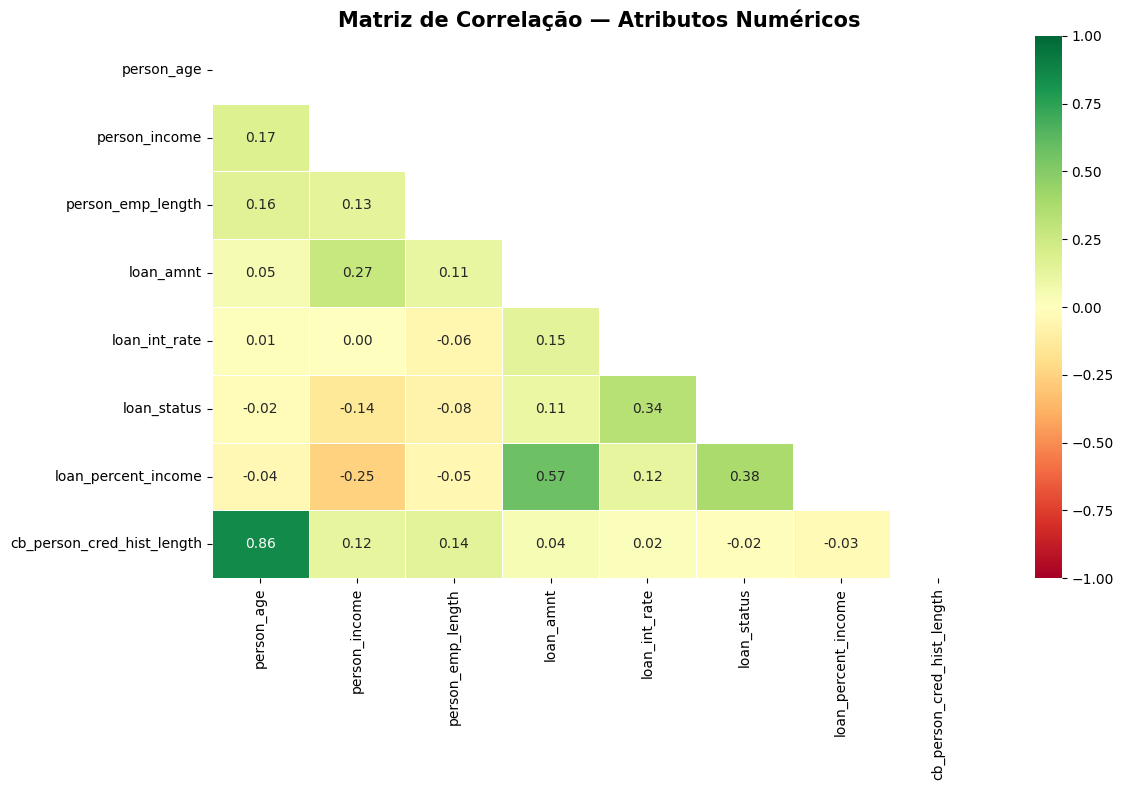

── Correlação com loan_status (ranking) ──
loan_percent_income           0.379366
loan_int_rate                 0.335133
person_income                 0.144449
loan_amnt                     0.105376
person_emp_length             0.082489
person_age                    0.021629
cb_person_cred_hist_length    0.015529


In [52]:
# matriz de correlação dos atributos numéricos
corr_matrix = df[num_cols].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(corr_matrix,
            mask=mask,
            annot=True, fmt='.2f',
            cmap='RdYlGn', center=0,
            vmin=-1, vmax=1,
            linewidths=0.5,
            ax=ax)
ax.set_title('Matriz de Correlação — Atributos Numéricos',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

# ranking de correlação com a variável-alvo
print('── Correlação com loan_status (ranking) ──')
print(corr_matrix['loan_status']
      .drop('loan_status')
      .abs()
      .sort_values(ascending=False)
      .to_string())

A matriz de correlação revela padrões relevantes para o problema:

- `loan_int_rate` apresenta a maior correlação com `loan_status`
(0.34), confirmando que a taxa de juros é o atributo numérico com
maior poder discriminante — faz sentido, pois a taxa já incorpora
o risco avaliado na concessão.
- `loan_percent_income` aparece em segundo lugar (0.38 com
`loan_status`), suportando a Hipótese 1 sobre o papel do DTI
como preditor de default.
- `person_age` e `cb_person_cred_hist_length` apresentam correlação
muito alta entre si (0.86) — pessoas mais velhas naturalmente
acumulam mais tempo de histórico de crédito. Esse nível de correlação
merece atenção no momento da modelagem para evitar multicolinearidade.
- `loan_amnt` e `loan_percent_income` têm correlação moderada (0.57)
— empréstimos maiores tendem a comprometer mais a renda do tomador.
- `person_income` tem correlação negativa com `loan_percent_income`
(-0.25) — quanto maior a renda, menor o comprometimento relativo,
o que é matematicamente esperado dado que o DTI divide o valor do
empréstimo pela renda.

# Tratamento de Valores Nulos

── Atributos com valores nulos ──
                   Qtd. Nulos  % do Total
loan_int_rate            3116        9.56
person_emp_length         895        2.75


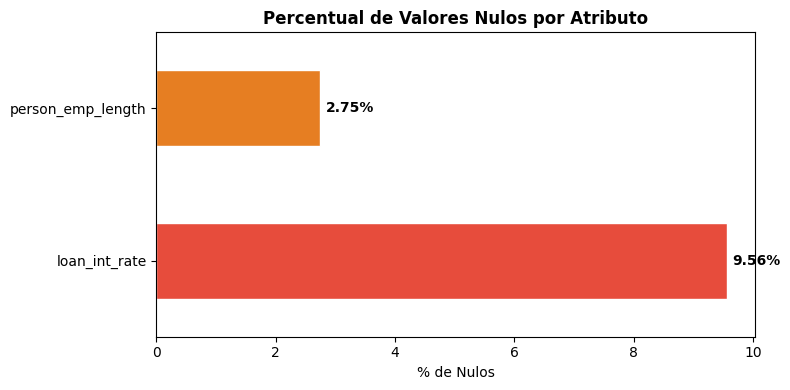

In [53]:
# diagnóstico de valores nulos
missing = pd.DataFrame({
    'Qtd. Nulos' : df.isnull().sum(),
    '% do Total' : (df.isnull().sum() / len(df) * 100).round(2)
}).query('`Qtd. Nulos` > 0').sort_values('% do Total', ascending=False)

print('── Atributos com valores nulos ──')
print(missing.to_string())

# visualização
fig, ax = plt.subplots(figsize=(8, 4))
missing['% do Total'].plot(kind='barh', ax=ax,
                           color=['#e74c3c', '#e67e22'],
                           edgecolor='white')
ax.set_title('Percentual de Valores Nulos por Atributo', fontweight='bold')
ax.set_xlabel('% de Nulos')
for i, v in enumerate(missing['% do Total']):
    ax.text(v + 0.1, i, f'{v}%', va='center', fontweight='bold')
plt.tight_layout()
plt.show()

In [54]:
# imputação pela mediana — robusta a outliers
mediana_taxa = df['loan_int_rate'].median()
df['loan_int_rate'] = df['loan_int_rate'].fillna(mediana_taxa)
print(f'✓ loan_int_rate: nulos imputados com mediana = {mediana_taxa:.2f}%')

mediana_emp = df['person_emp_length'].median()
df['person_emp_length'] = df['person_emp_length'].fillna(mediana_emp)
print(f'✓ person_emp_length: nulos imputados com mediana = {mediana_emp:.1f} anos')

print(f'\n✓ Valores nulos restantes: {df.isnull().sum().sum()}')

✓ loan_int_rate: nulos imputados com mediana = 10.99%
✓ person_emp_length: nulos imputados com mediana = 4.0 anos

✓ Valores nulos restantes: 0


A **mediana** foi escolhida como estratégia de imputação por duas razões:

- **Robustez a outliers**: ambas as variáveis apresentam outliers
extremos detectados na análise descritiva. A média seria distorcida
por esses valores, enquanto a mediana é insensível a eles.
- **Proporção baixa de nulos**: com menos de 10% de valores ausentes
em ambos os atributos, a imputação pela mediana preserva a distribuição
central sem introduzir viés relevante.

# Pré-Processamento de Dados

## Normalização

In [55]:
# remoção de outliers impossíveis antes de normalizar
n_antes = len(df)
df = df[df['person_age'] <= 90]
df = df[df['person_emp_length'] <= 60]
n_depois = len(df)
print(f'✓ Outliers removidos: {n_antes - n_depois:,} registros ({(n_antes - n_depois)/n_antes*100:.2f}%)')
print(f'✓ Dataset resultante: {n_depois:,} registros')

# normalização Min-Max — escala [0, 1]
# indicada para algoritmos sensíveis à magnitude: KNN, SVM, Redes Neurais
cols_num = ['person_age', 'person_income', 'person_emp_length',
            'loan_amnt', 'loan_int_rate', 'loan_percent_income',
            'cb_person_cred_hist_length']

scaler_minmax = MinMaxScaler()
df_normalizado = df.copy()
df_normalizado[cols_num] = scaler_minmax.fit_transform(df[cols_num])

print('\n── Resumo após normalização Min-Max ──')
df_normalizado[cols_num].describe().round(3)

✓ Outliers removidos: 8 registros (0.02%)
✓ Dataset resultante: 32,573 registros

── Resumo após normalização Min-Max ──


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,32573.000,32573.000,32573.000,32573.000,32573.000,32573.000,32573.000
mean,0.121,0.030,0.116,0.263,0.314,0.205,0.136
std,0.097,0.026,0.097,0.183,0.173,0.129,0.145
min,0.000,0.000,0.000,0.000,0.000,0.000,0.000
25%,0.047,0.017,0.049,0.130,0.172,0.108,0.036
50%,0.094,0.025,0.098,0.217,0.313,0.181,0.071
75%,0.156,0.037,0.171,0.339,0.432,0.277,0.214
max,1.000,1.000,1.000,1.000,1.000,1.000,1.000


Antes da normalização, removemos registros com valores impossíveis em
`person_age` (> 90 anos) e `person_emp_length` (> 60 anos), pois
representam inconsistências cadastrais e não refletem dados reais.

A normalização **Min-Max** escala todos os atributos numéricos para o
intervalo [0, 1], eliminando o efeito da diferença de magnitude entre
variáveis. Após a transformação, todos os atributos apresentam mínimo
0 e máximo 1, confirmando a aplicação correta.

## Padronização

In [56]:
# padronização Z-score — média=0, desvio padrão=1
# indicada para modelos lineares: Regressão Logística, LDA
scaler_std = StandardScaler()
df_padronizado = df.copy()
df_padronizado[cols_num] = scaler_std.fit_transform(df[cols_num])

print('── Resumo após padronização Z-score ──')
df_padronizado[cols_num].describe().round(3)

── Resumo após padronização Z-score ──


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,32573.000,32573.000,32573.000,32573.000,32573.000,32573.000,32573.000
mean,0.000,0.000,-0.000,-0.000,-0.000,0.000,-0.000
std,1.000,1.000,1.000,1.000,1.000,1.000,1.000
min,-1.246,-1.178,-1.196,-1.438,-1.814,-1.594,-0.939
25%,-0.761,-0.521,-0.693,-0.726,-0.818,-0.751,-0.692
50%,-0.277,-0.207,-0.191,-0.251,-0.006,-0.189,-0.445
75%,0.369,0.254,0.562,0.413,0.682,0.560,0.542
max,9.087,37.576,9.103,4.021,3.962,6.181,5.971


A padronização **Z-score** transforma cada atributo para ter média
próxima de zero e desvio padrão igual a 1. Diferente da normalização
Min-Max, não limita os valores a um intervalo fixo — outliers ainda
aparecem, porém agora expressos em número de desvios padrão em relação
à média.

As duas versões do dataset foram salvas separadamente:
- `df_normalizado` → usar com KNN, SVM, Redes Neurais
- `df_padronizado` → usar com Regressão Logística, LDA

## Outras Transformações e Etapas de Pré-Processamento

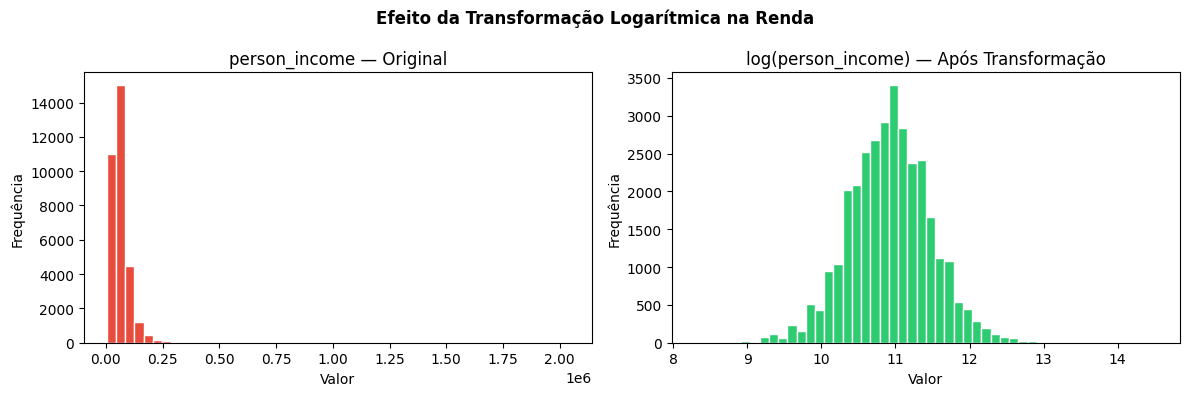

Skewness original : 9.756
Skewness após log : 0.139


In [57]:
# transformação logarítmica em person_income
# corrige a forte assimetria positiva identificada nos histogramas
df_preprocessado = df.copy()
df_preprocessado['log_person_income'] = np.log1p(df['person_income'])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df['person_income'], bins=50,
             color='#e74c3c', edgecolor='white')
axes[0].set_title('person_income — Original')
axes[0].set_xlabel('Valor')
axes[0].set_ylabel('Frequência')

axes[1].hist(df_preprocessado['log_person_income'], bins=50,
             color='#2ecc71', edgecolor='white')
axes[1].set_title('log(person_income) — Após Transformação')
axes[1].set_xlabel('Valor')
axes[1].set_ylabel('Frequência')

plt.suptitle('Efeito da Transformação Logarítmica na Renda',
             fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Skewness original : {stats.skew(df["person_income"]):.3f}')
print(f'Skewness após log : {stats.skew(df_preprocessado["log_person_income"]):.3f}')

A transformação `log(1 + x)` reduziu drasticamente o skewness de
`person_income`, aproximando a distribuição da normalidade. O histograma
original mostra quase toda a massa concentrada abaixo de 0.25M, com
cauda direita muito longa. Após a transformação, a distribuição assume
formato simétrico e bem comportado, centrado em torno de 11.

Isso beneficia modelos lineares que assumem distribuição simétrica dos
preditores e reduz a influência desproporcional de rendas muito altas
no treinamento.

In [58]:
# encoding ordinal em loan_grade
# preserva a ordem de risco: A (menor) → G (maior)
le = LabelEncoder()
df_preprocessado['loan_grade_enc'] = le.fit_transform(df['loan_grade'])

# verificação do mapeamento
mapeamento = pd.DataFrame({
    'loan_grade'     : le.classes_,
    'loan_grade_enc' : le.transform(le.classes_)
})
print('── Mapeamento loan_grade ──')
print(mapeamento.to_string(index=False))

── Mapeamento loan_grade ──
loan_grade  loan_grade_enc
         A               0
         B               1
         C               2
         D               3
         E               4
         F               5
         G               6


O `LabelEncoder` foi aplicado em `loan_grade` por se tratar de uma
variável **ordinal** — existe uma ordem semântica clara entre as
categorias (A < B < C < D < E < F < G), onde cada letra representa
um nível crescente de risco.

Diferente do One-Hot Encoding, que trataria cada grade como categoria
independente, o encoding ordinal preserva essa relação de ordem,
permitindo que modelos futuros capturem a progressão de risco entre
as grades.

In [59]:
# one-hot encoding nas variáveis categóricas nominais
# aplicado em variáveis sem ordem natural entre categorias
cat_cols = ['person_home_ownership', 'loan_intent', 'cb_person_default_on_file']

df_preprocessado = pd.get_dummies(df_preprocessado,
                                   columns=cat_cols,
                                   drop_first=True,
                                   dtype=int)

print(f'✓ Colunas antes do encoding : {df.shape[1]}')
print(f'✓ Colunas após o encoding   : {df_preprocessado.shape[1]}')
print(f'\n── Novas colunas criadas ──')
novas_cols = [c for c in df_preprocessado.columns if c not in df.columns]
print(novas_cols)

✓ Colunas antes do encoding : 12
✓ Colunas após o encoding   : 20

── Novas colunas criadas ──
['log_person_income', 'loan_grade_enc', 'person_home_ownership_OTHER', 'person_home_ownership_OWN', 'person_home_ownership_RENT', 'loan_intent_EDUCATION', 'loan_intent_HOMEIMPROVEMENT', 'loan_intent_MEDICAL', 'loan_intent_PERSONAL', 'loan_intent_VENTURE', 'cb_person_default_on_file_Y']


O **One-Hot Encoding** foi aplicado nas variáveis categóricas nominais
`person_home_ownership`, `loan_intent` e `cb_person_default_on_file`,
pois essas variáveis não possuem ordem natural entre suas categorias.

O parâmetro `drop_first=True` remove uma categoria de referência em
cada variável, evitando a **dummy variable trap** — situação em que
uma coluna pode ser perfeitamente prevista pelas demais, introduzindo
multicolinearidade perfeita no modelo.

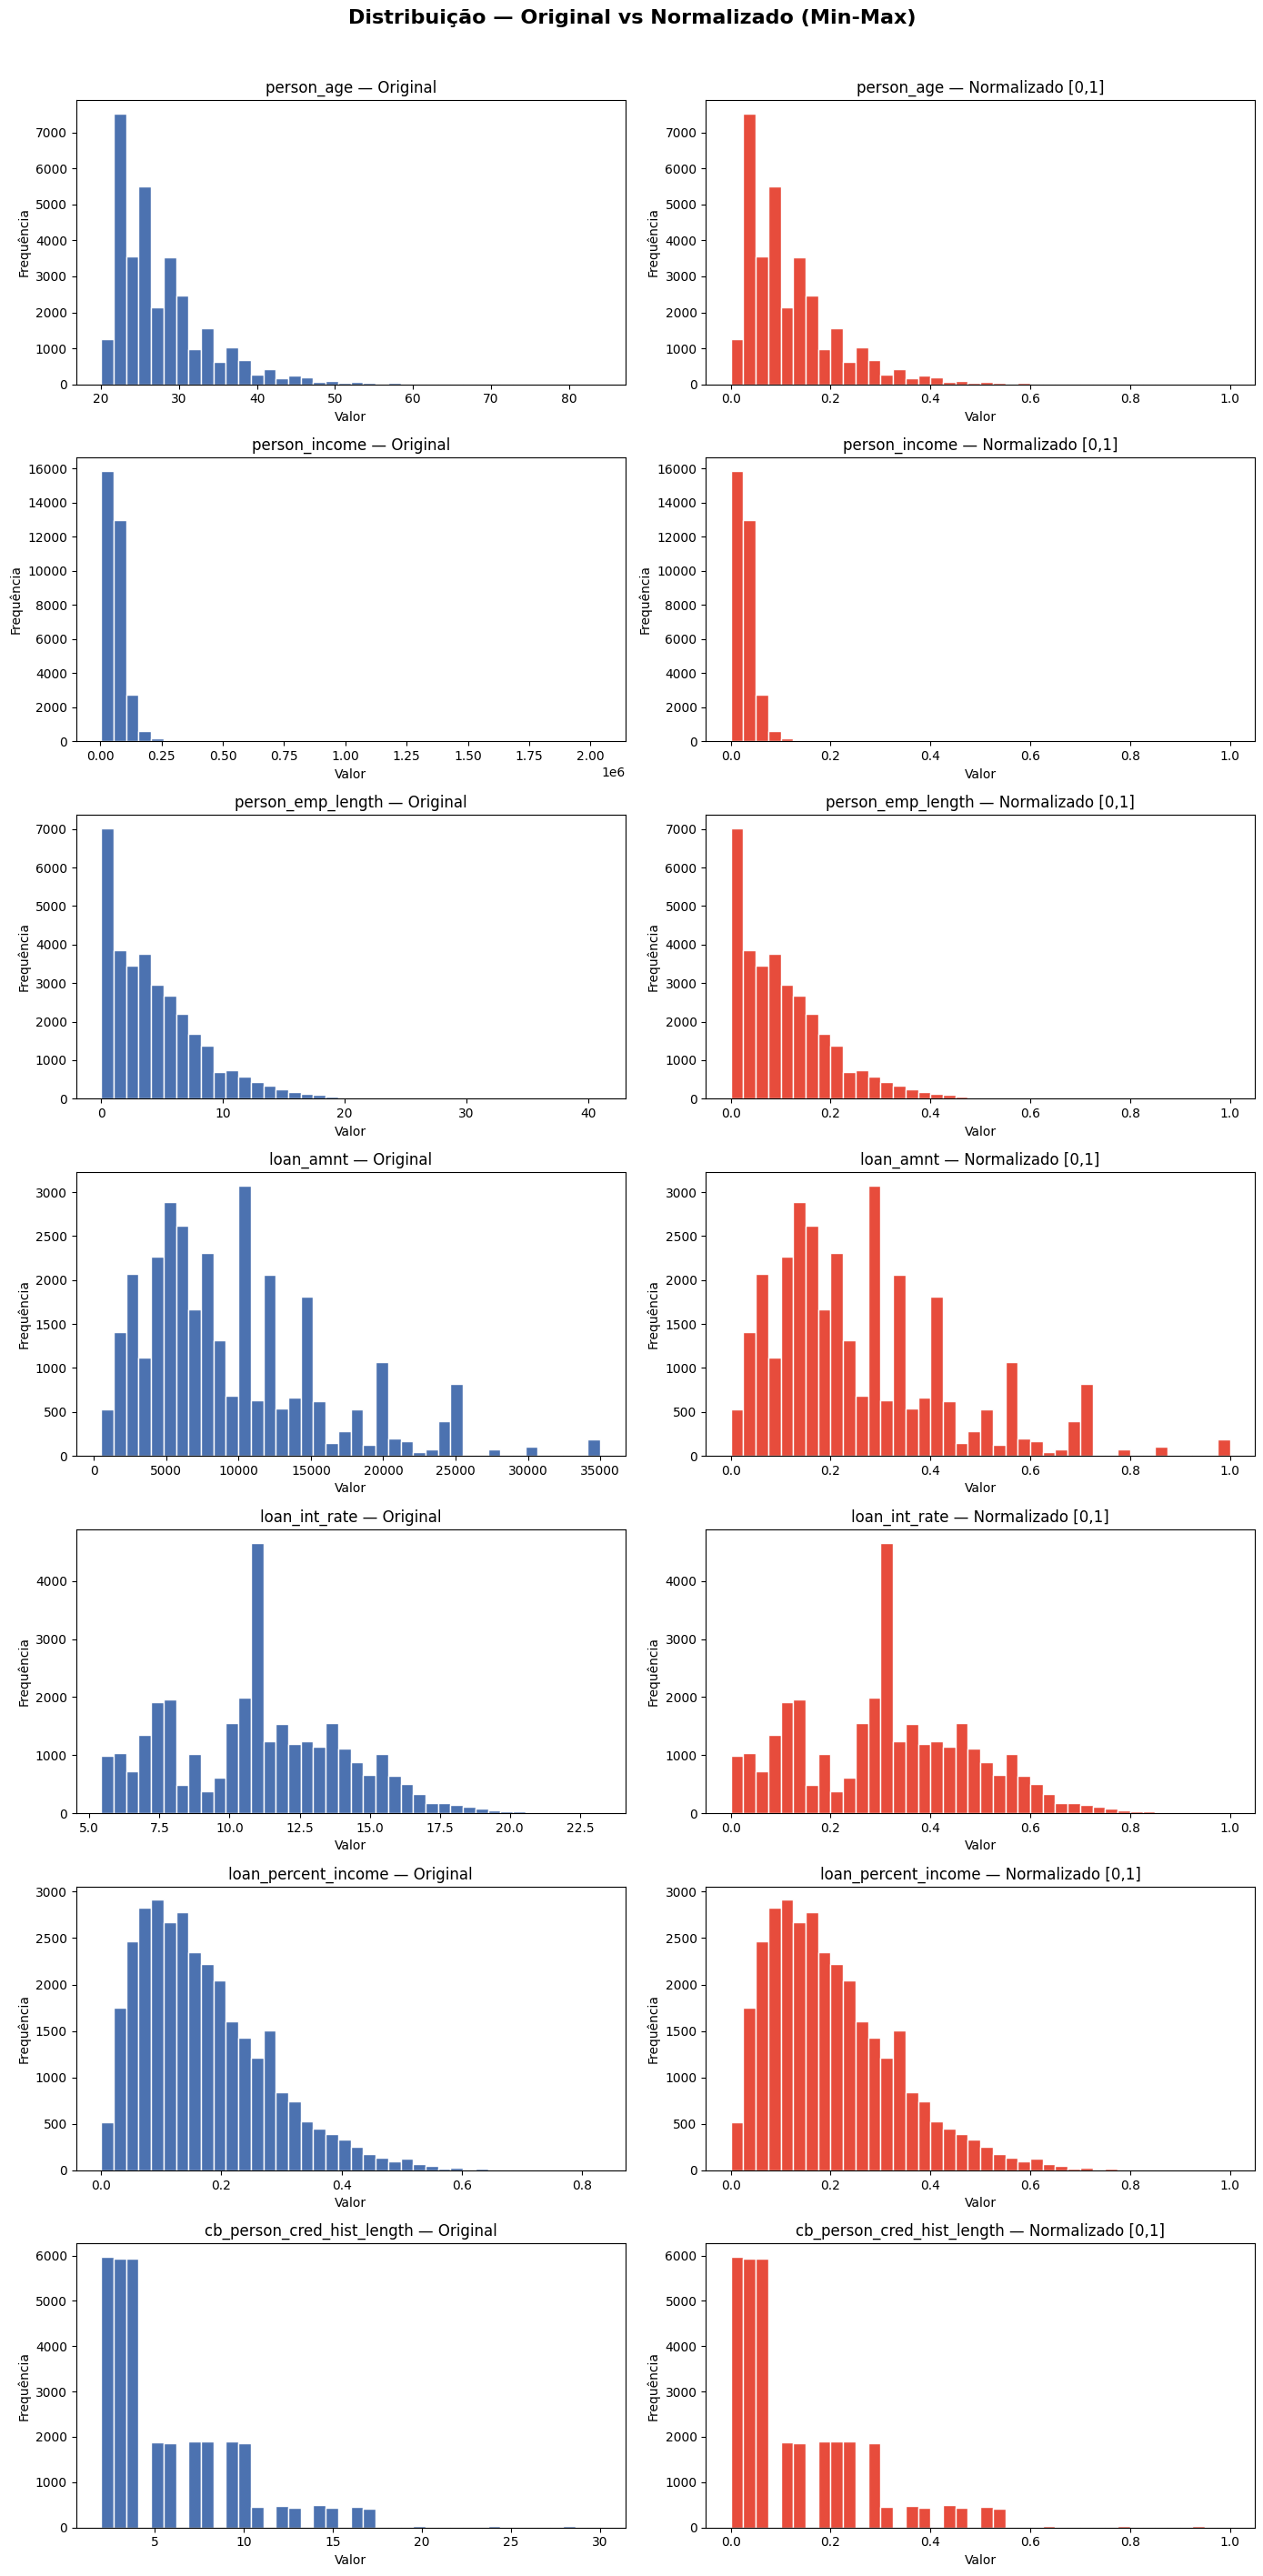

In [60]:
# verificação da distribuição após pré-processamento
# comparando original vs normalizado em subplots separados
cols_plot = [c for c in cols_num if c != 'loan_status']

fig, axes = plt.subplots(len(cols_plot), 2, figsize=(14, 28))

for i, col in enumerate(cols_plot):
    # original
    axes[i, 0].hist(df[col].dropna(), bins=40,
                    color='#4C72B0', edgecolor='white')
    axes[i, 0].set_title(f'{col} — Original')
    axes[i, 0].set_xlabel('Valor')
    axes[i, 0].set_ylabel('Frequência')

    # normalizado
    axes[i, 1].hist(df_normalizado[col].dropna(), bins=40,
                    color='#e74c3c', edgecolor='white')
    axes[i, 1].set_title(f'{col} — Normalizado [0,1]')
    axes[i, 1].set_xlabel('Valor')
    axes[i, 1].set_ylabel('Frequência')

plt.suptitle('Distribuição — Original vs Normalizado (Min-Max)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Os histogramas confirmam o comportamento esperado da normalização
Min-Max: as distribuições original e normalizada são visualmente
idênticas — apenas o eixo X muda, sendo reescalado para o intervalo
[0, 1] em todos os atributos.

Isso demonstra que a normalização Min-Max é uma transformação
**monotônica** — preserva a ordem e o formato da distribuição original,
sem distorcer os dados. Assimetrias e padrões identificados na análise
exploratória permanecem intactos.

O valor real dessa transformação aparece na modelagem: algoritmos como
KNN e SVM passam a tratar todos os atributos na mesma escala, evitando
que variáveis com maior magnitude (como `person_income`) dominem o
cálculo de distâncias e pesos.

# Respondendo hipóteses

## Hipótese 1
**Tomadores com maior comprometimento de renda (DTI) apresentam maior
probabilidade de default.**

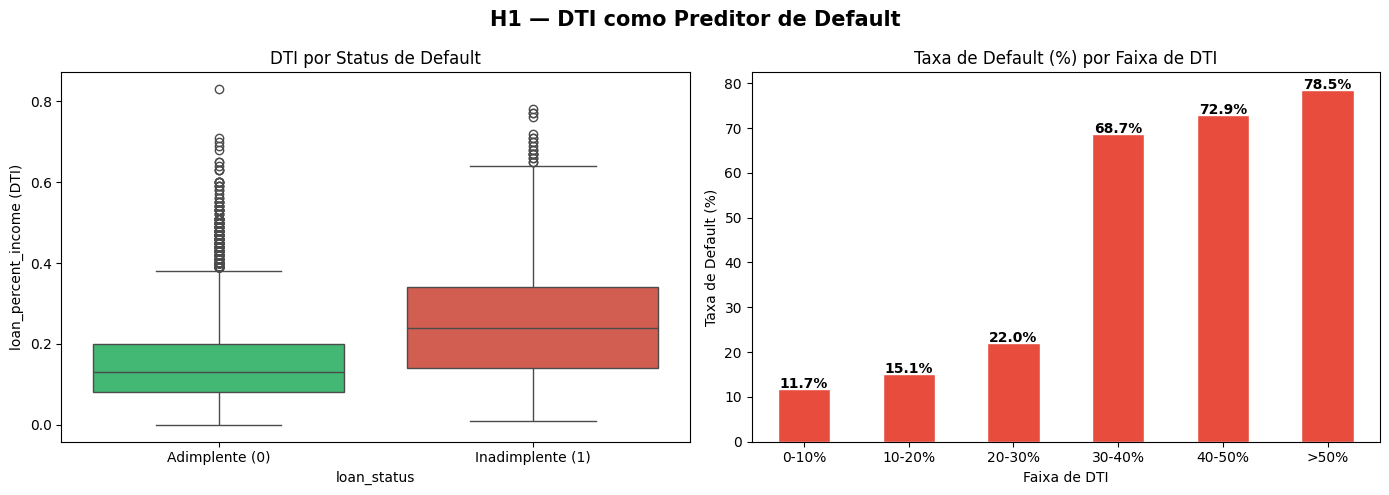

In [61]:
# H1: loan_percent_income (DTI) x loan_status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# boxplot DTI por classe
sns.boxplot(data=df, x='loan_status', y='loan_percent_income',
            hue='loan_status',
            palette={0: '#2ecc71', 1: '#e74c3c'},
            legend=False, ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Adimplente (0)', 'Inadimplente (1)'])
axes[0].set_title('DTI por Status de Default')
axes[0].set_ylabel('loan_percent_income (DTI)')

# taxa de default por faixa de DTI
df['dti_faixa'] = pd.cut(df['loan_percent_income'],
                          bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0],
                          labels=['0-10%','10-20%','20-30%',
                                  '30-40%','40-50%','>50%'])
default_dti = df.groupby('dti_faixa', observed=True)['loan_status'].mean() * 100
default_dti.plot(kind='bar', ax=axes[1],
                 color='#e74c3c', edgecolor='white')
axes[1].set_title('Taxa de Default (%) por Faixa de DTI')
axes[1].set_ylabel('Taxa de Default (%)')
axes[1].set_xlabel('Faixa de DTI')
axes[1].tick_params(axis='x', rotation=0)
for i, v in enumerate(default_dti):
    axes[1].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')

plt.suptitle('H1 — DTI como Preditor de Default', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()
df.drop(columns='dti_faixa', inplace=True)


**Resultado 1:** A taxa de default cresce de forma
consistente e acentuada com o aumento do DTI:

- DTI 0-10%: 11.7% de default
- DTI 10-20%: 15.1% de default
- DTI 20-30%: 22.0% de default
- DTI 30-40%: 68.7% de default
- DTI 40-50%: 72.9% de default
- DTI > 50%: 78.5% de default

O salto mais expressivo ocorre entre a faixa 20-30% e 30-40%,
sugerindo que o DTI de 30% funciona como um ponto crítico de
comprometimento de renda — acima dele, a probabilidade de default
aumenta drasticamente. Esse resultado reforça a prática de
instituições financeiras de adotar 30% como limite máximo de DTI
em políticas de concessão de crédito responsável.

## Hipótese 2
**Clientes com histórico de default anterior têm maior taxa de
inadimplência futura.**

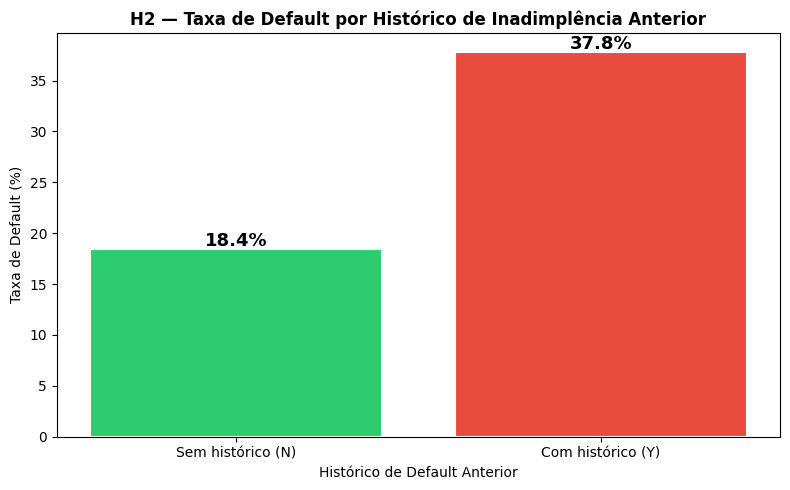

In [62]:
# H2: cb_person_default_on_file x loan_status
default_hist = df.groupby('cb_person_default_on_file')['loan_status'].mean() * 100

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(default_hist.index, default_hist.values,
              color=['#2ecc71', '#e74c3c'], edgecolor='white', linewidth=1.5)
ax.set_title('H2 — Taxa de Default por Histórico de Inadimplência Anterior',
             fontweight='bold')
ax.set_ylabel('Taxa de Default (%)')
ax.set_xlabel('Histórico de Default Anterior')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Sem histórico (N)', 'Com histórico (Y)'])
for bar, v in zip(bars, default_hist.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3,
            f'{v:.1f}%', ha='center', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

**Resultado 2:** Clientes com histórico de default anterior
apresentam taxa de inadimplência de 37.8%, mais que o dobro dos clientes
sem histórico (18.4%).

Esse resultado confirma que comportamento passado de crédito é o preditor
mais direto de risco futuro — princípio que fundamenta sistemas de
compartilhamento de dados negativos como o Cadastro Positivo no Brasil
(Lei 12.414/2011). Na prática, essa variável tende a receber peso elevado
em qualquer scorecard de concessão, pois captura um padrão comportamental
difícil de reverter no curto prazo.

## Hipótese 3
**A taxa de default cresce progressivamente do loan grade A ao G.**

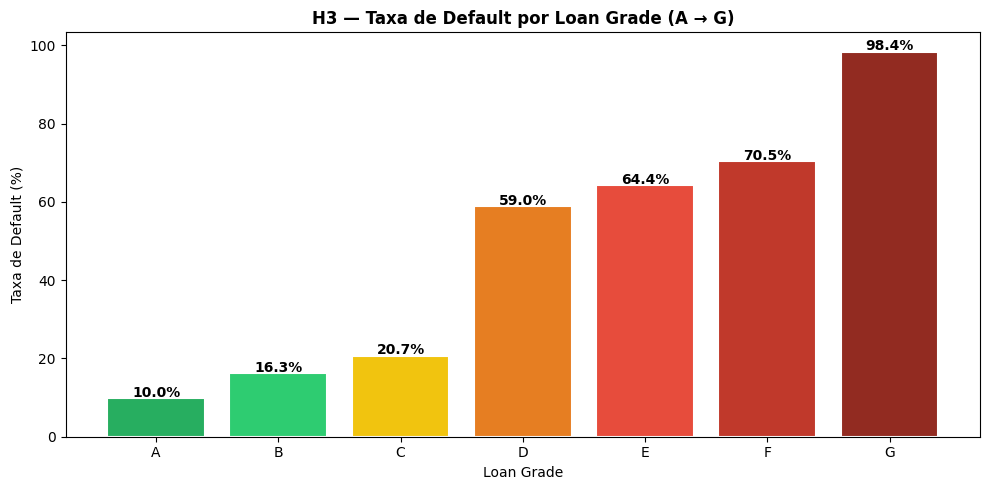

In [63]:
# H3: loan_grade x taxa de default
default_grade = (df.groupby('loan_grade')['loan_status']
                 .mean() * 100).reindex(['A','B','C','D','E','F','G'])

fig, ax = plt.subplots(figsize=(10, 5))
cores = ['#27ae60','#2ecc71','#f1c40f','#e67e22','#e74c3c','#c0392b','#922b21']
bars = ax.bar(default_grade.index, default_grade.values,
              color=cores, edgecolor='white', linewidth=1.5)
ax.set_title('H3 — Taxa de Default por Loan Grade (A → G)', fontweight='bold')
ax.set_ylabel('Taxa de Default (%)')
ax.set_xlabel('Loan Grade')
for bar, v in zip(bars, default_grade.values):
    ax.text(bar.get_x() + bar.get_width()/2, v + 0.3,
            f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Resultado 3:** A taxa de default cresce monotonicamente
da grade A para a G, sem nenhuma inversão:

- Grade A: 10.0%
- Grade B: 16.3%
- Grade C: 20.7%
- Grade D: 59.0%
- Grade E: 64.4%
- Grade F: 70.5%
- Grade G: 98.4%

Dois achados se destacam. Primeiro, o salto entre C (20.7%) e D (59.0%)
é o mais expressivo de toda a escala — um aumento de quase 40pp,
sugerindo que a grade D representa uma mudança qualitativa no perfil
de risco do tomador, não apenas uma graduação incremental.

Segundo, a grade G apresenta taxa de 98.4%, indicando que praticamente
todos os tomadores nessa categoria entraram em default. Isso levanta
uma questão relevante do ponto de vista de negócio: por que a instituição
concedeu crédito a tomadores grade G? Pode indicar concessões com
garantias reais não capturadas no dataset, ou simplesmente uma política
de crédito agressiva para esse segmento.

Esse resultado confirma que o `loan_grade` é uma variável de altíssimo
poder preditivo e deve ser tratada como feature prioritária em qualquer
modelo de PD.

## Hipótese 4
**Empréstimos para fins médicos e consolidação de dívidas apresentam
maior taxa de default.**

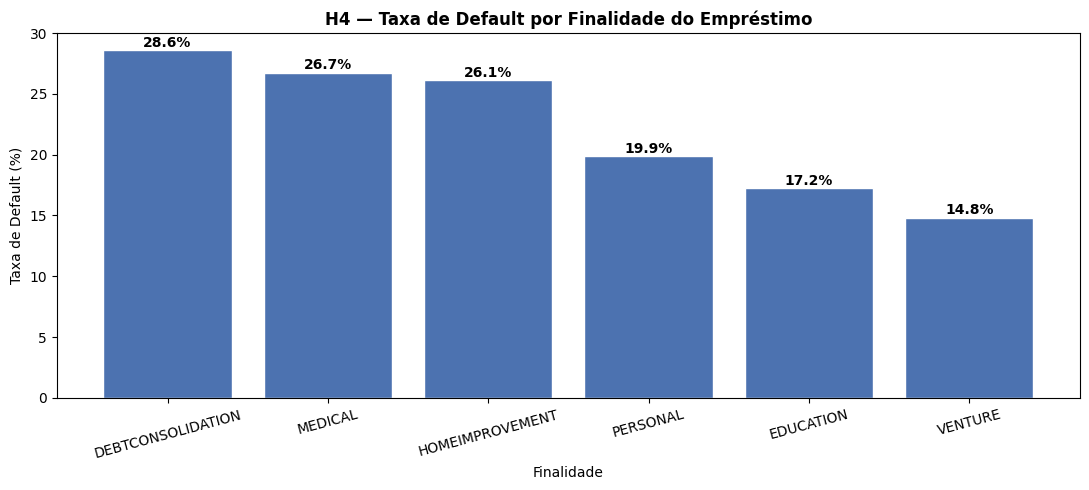

In [64]:
# H4: loan_intent x taxa de default
default_intent = (df.groupby('loan_intent')['loan_status']
                  .mean() * 100).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.bar(default_intent.index, default_intent.values,
              color='#4C72B0', edgecolor='white')
ax.set_title('H4 — Taxa de Default por Finalidade do Empréstimo',
             fontweight='bold')
ax.set_ylabel('Taxa de Default (%)')
ax.set_xlabel('Finalidade')
ax.tick_params(axis='x', rotation=15)
for i, v in enumerate(default_intent.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

**Resultado 4: DEBTCONSOLIDATION (28.6%) e
MEDICAL (26.7%) lideram o ranking de default, confirmando a hipótese
para essas duas finalidades. Contudo, HOMEIMPROVEMENT (26.1%) aparece
em terceiro lugar — resultado inesperado, já que empréstimos para
melhoria residencial tipicamente indicam estabilidade financeira.

Outro achado surpreendente é VENTURE (14.8%) como a menor taxa de
default, contrariando a intuição de que empréstimos para negócios
representariam maior risco.

A diferença entre a maior (28.6%) e menor (14.8%) taxa é de apenas
13.8pp — bem mais estreita do que o observado em `loan_grade` ou DTI.
Isso sugere que a finalidade do empréstimo, isoladamente, tem poder
discriminante moderado. Seu valor preditivo deve ser maior quando
combinado com outras variáveis como DTI e `loan_grade` em um modelo
multivariado.

## Hipótese 5
**Clientes mais jovens apresentam maior risco de default.**

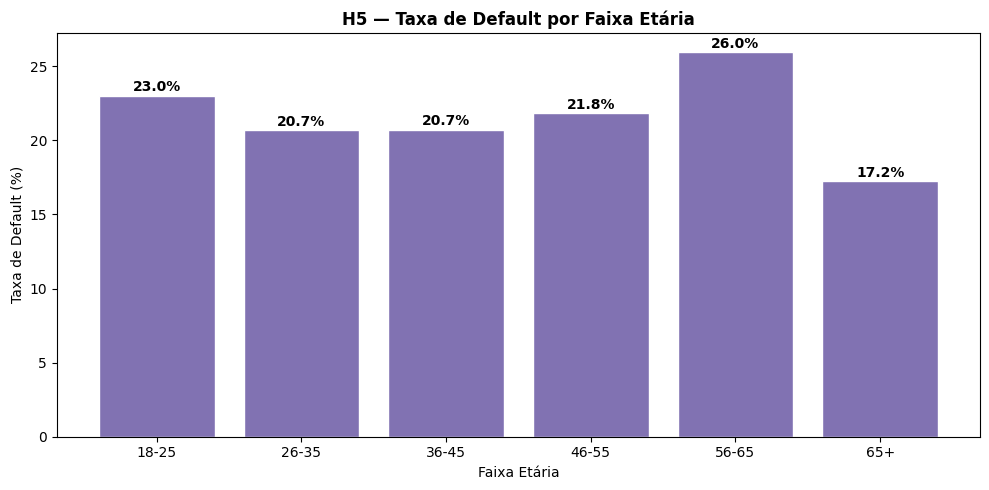

In [65]:
# H5: person_age x taxa de default por faixa etária
df['age_faixa'] = pd.cut(df['person_age'],
                          bins=[18, 25, 35, 45, 55, 65, 90],
                          labels=['18-25','26-35','36-45',
                                  '46-55','56-65','65+'])
default_age = df.groupby('age_faixa', observed=True)['loan_status'].mean() * 100

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(default_age.index, default_age.values,
              color='#8172B2', edgecolor='white')
ax.set_title('H5 — Taxa de Default por Faixa Etária', fontweight='bold')
ax.set_ylabel('Taxa de Default (%)')
ax.set_xlabel('Faixa Etária')
ax.tick_params(axis='x', rotation=0)
for i, v in enumerate(default_age.values):
    ax.text(i, v + 0.3, f'{v:.1f}%', ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

df.drop(columns='age_faixa', inplace=True)

**Resultado 5:** A faixa 18-25 anos apresenta
a maior taxa de default (23.0%), o que confirma a hipótese para os
mais jovens. Porém, o comportamento geral não é monotônico como esperado
— a faixa 56-65 anos surpreende com a maior taxa de todo o dataset
(26.0%), superando inclusive os jovens.

Esse padrão sugere uma relação em forma de "U invertido assimétrico":
- **18-25 anos (23.0%)**: maior risco por instabilidade de renda e
histórico de crédito curto
- **26-55 anos (20.7% - 21.8%)**: faixa de menor risco, com maior
estabilidade financeira e experiência de crédito
- **56-65 anos (26.0%)**: risco elevado novamente, possivelmente
associado a aproximação da aposentadoria e redução de renda
- **65+ anos (17.2%)**: queda inesperada, que pode refletir menor
volume de tomadores nessa faixa ou perfil mais conservador de crédito

A amplitude total entre faixas é de apenas 8.8pp, indicando que a
idade isoladamente tem poder discriminante limitado. A relação
não-linear observada reforça a necessidade de tratamento especial
dessa variável em modelos futuros, como binning ou transformações
polinomiais.

## Hipótese 6
**O dataset apresenta desbalanceamento de classes — inadimplentes
são a classe minoritária.**

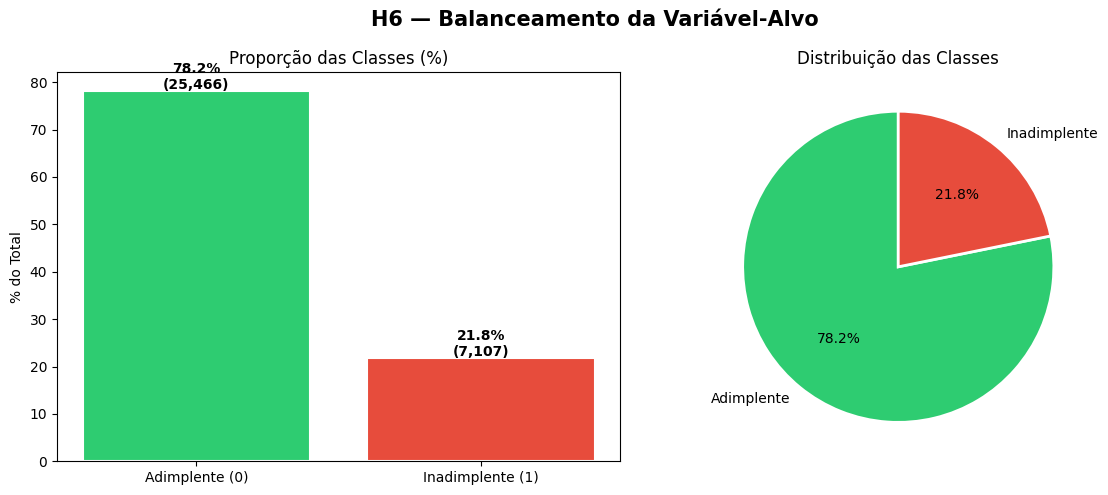

Total adimplentes  : 25,466 (78.2%)
Total inadimplentes: 7,107 (21.8%)
Ratio              : 3.6:1


In [66]:
# H6: distribuição da variável-alvo
target_pct = df['loan_status'].value_counts(normalize=True) * 100
target_cnt = df['loan_status'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# barplot
bars = axes[0].bar(['Adimplente (0)', 'Inadimplente (1)'],
                   target_pct.values,
                   color=['#2ecc71', '#e74c3c'],
                   edgecolor='white', linewidth=1.5)
axes[0].set_title('Proporção das Classes (%)')
axes[0].set_ylabel('% do Total')
for bar, pct, cnt in zip(bars, target_pct.values, target_cnt.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, pct + 0.3,
                 f'{pct:.1f}%\n({cnt:,})', ha='center', fontweight='bold')

# pizza
axes[1].pie(target_cnt.values,
            labels=['Adimplente', 'Inadimplente'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Distribuição das Classes')

plt.suptitle('H6 — Balanceamento da Variável-Alvo',
             fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Total adimplentes  : {target_cnt[0]:,} ({target_pct[0]:.1f}%)')
print(f'Total inadimplentes: {target_cnt[1]:,} ({target_pct[1]:.1f}%)')
print(f'Ratio              : {target_cnt[0]/target_cnt[1]:.1f}:1')

**Resultado 6:** O dataset apresenta desbalanceamento de
classes com taxa de 3.6:1 — para cada inadimplente, há 3.6 adimplentes:

- Adimplentes: 25.466 registros (78.2%)
- Inadimplentes: 7.107 registros (21.8%)

O desbalanceamento é moderado — não tão severo quanto carteiras de
crédito premium (onde o default pode ser < 5%), mas suficiente para
impactar modelos preditivos. Um classificador ingênuo que previsse
sempre "adimplente" já acertaria 78.2% dos casos, sem aprender nada
sobre o padrão real de inadimplência.

Antes da modelagem, recomenda-se aplicar uma das seguintes estratégias:
- **SMOTE**: geração sintética de amostras da classe minoritária
- **Undersampling**: redução da classe majoritária
- **class_weight='balanced'**: ajuste de pesos no próprio algoritmo

A métrica de avaliação primária deve ser **AUC-ROC** ou **KS statistic**,
não acurácia simples — que seria enganosa dado o desbalanceamento.

# Conclusão

Este trabalho conduziu uma análise exploratória completa e um pipeline
de pré-processamento sobre o Credit Risk Dataset, cobrindo todas as
etapas necessárias para preparar os dados para modelagem preditiva de
Probabilidade de Default (PD).

## Resumo das Hipóteses

| Hipótese | Resultado | Insight Principal |
|----------|-----------|-------------------|
| H1 — DTI prediz default |  Confirmada | Salto crítico na faixa de 30% de DTI — taxa passa de 22% para 68.7% |
| H2 — Histórico anterior é o maior preditor |  Confirmada | Com histórico: 37.8% vs sem histórico: 18.4% de default |
| H3 — Default cresce A → G |  Confirmada | `loan_grade` é a variável de maior poder discriminante — grade G chega a 98.4% |
| H4 — Finalidade como proxy de estresse |  Parcial | DEBTCONSOLIDATION lidera (28.6%), mas diferença entre categorias é moderada |
| H5 — Jovens têm maior risco |  Parcial | Confirmada para jovens (23%), mas faixa 56-65 surpreende com 26% |
| H6 — Desbalanceamento de classes |  Confirmada | Ratio 3.6:1 — requer tratamento antes da modelagem |

## Decisões de Pré-Processamento

As seguintes transformações foram aplicadas e justificadas ao longo
do trabalho:

- **Remoção de outliers impossíveis**: `person_age` > 90 anos e
`person_emp_length` > 60 anos removidos por violarem restrições
do mundo real
- **Imputação pela mediana**: aplicada em `loan_int_rate` e
`person_emp_length`, escolhida por sua robustez a outliers
- **Normalização Min-Max**: dataset escalado para [0,1], indicado
para algoritmos sensíveis à magnitude
- **Padronização Z-score**: dataset centralizado em média=0 e
desvio=1, indicado para modelos lineares
- **Transformação logarítmica**: aplicada em `person_income` para
corrigir forte assimetria positiva
- **Encoding ordinal**: aplicado em `loan_grade` preservando a
ordem semântica de risco A → G
- **One-Hot Encoding**: aplicado nas variáveis categóricas nominais
`person_home_ownership`, `loan_intent` e `cb_person_default_on_file`

## Próximos Passos

O dataset pré-processado está pronto para a etapa de modelagem.
Recomenda-se avaliar **Regressão Logística** (alta interpretabilidade
e padrão regulatório), **Gradient Boosting** (melhor performance
preditiva) e **Random Forest** (equilíbrio entre performance e
interpretabilidade). A métrica primária deve ser **AUC-ROC**,
complementada pelo **KS statistic** — métrica padrão da indústria
de crédito para avaliação de modelos de PD.